In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [57]:
from sklearn.preprocessing import StandardScaler

In [8]:
#loading the dataset to a Pandas DataFrame
credit_card_data = pd.read_csv('/content/creditcard.csv')

In [9]:
#first 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [11]:
#dataset information
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
#checking the number of missing valuesin each column
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [14]:
#distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


This Dataset is highly unbalanced

0 --> Normal Transactions

1 --> Fraudulent Transactions

In [18]:
#separating the data for analysis
legit = credit_card_data[credit_card_data['Class'] == 0]
fraud = credit_card_data[credit_card_data['Class'] == 1]

In [19]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [21]:
#statistical measures of the data
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [22]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [23]:
#compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,-0.006576,0.010832,0.000189,0.012064,0.000161,0.007164,0.011535,0.003887,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Under-Sampling

Build a sample dataset containing similar distribution of normal transactions and fradulent transactions

Number of Fraudulent Transactions --> 492

In [35]:
legit_sample = legit.sample(n=492)

Concatenating two DataFrames

In [36]:
new_dataset=pd.concat([legit_sample, fraud], axis=0)

In [37]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
109516,71417.0,1.039946,0.063398,1.000667,1.234134,-0.511258,-0.014643,-0.253152,0.026725,0.122509,-0.107733,0.043579,1.073851,1.565108,-0.192207,1.347308,0.198488,-0.436163,-0.509253,-0.960175,0.047323,0.057159,0.170822,0.006583,0.101504,0.279325,-0.440699,0.067618,0.047473,60.51,0
91481,63488.0,0.870988,-1.452018,-0.350945,-0.411340,-1.077075,-0.486955,-0.080385,-0.112630,-0.843444,0.712095,0.413493,-0.228884,-1.302476,0.550232,-0.524135,-1.399378,0.034285,1.434488,-0.122991,-0.030893,-0.275242,-0.896856,-0.275242,0.030580,0.300516,1.071303,-0.132998,0.027680,273.03,0
153261,98357.0,2.175223,-0.402656,-1.735765,-0.144654,0.192044,-0.740028,0.054618,-0.499171,0.464882,0.509569,-0.137617,-2.159259,2.540556,1.568320,-1.347137,-2.177084,0.882009,0.683216,-0.790686,-0.569778,-0.499675,-0.548061,0.136142,0.586934,0.142400,0.542084,-0.102819,-0.069986,28.00,0
43630,41584.0,1.004997,-0.303465,0.260845,0.696737,-0.544737,-0.502679,-0.002985,-0.021545,0.299745,-0.095599,-0.330358,-0.417118,-1.202922,0.561919,1.439913,0.025464,-0.048903,-0.514296,-0.634038,0.005383,0.085307,0.005621,-0.093518,0.080115,0.299916,0.403196,-0.044445,0.026197,113.62,0
170096,120013.0,0.077997,0.967316,-2.004931,-0.799479,1.354203,0.176876,0.675828,0.388037,-0.360822,-0.884880,-0.314910,0.263776,0.157176,-0.592531,-0.974960,0.927757,-0.092625,0.738110,0.409003,-0.258021,-0.142050,-0.507989,0.158162,-0.853687,-0.645175,0.191094,-0.231633,-0.073250,43.40,0


In [38]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,-5.587794,2.115795,-5.417424,-1.235123,-6.665177,0.401701,-2.897825,-4.570529,-1.315147,0.391167,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,-3.232153,2.858466,-3.096915,-0.792532,-5.210141,-0.613803,-2.155297,-3.267116,-0.688505,0.737657,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,-3.463891,1.794969,-2.775022,-0.418950,-4.057162,-0.712616,-1.603015,-5.035326,-0.507000,0.266272,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,-5.245984,1.933520,-5.030465,-1.127455,-6.416628,0.141237,-2.549498,-4.614717,-1.478138,-0.035480,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,-0.888722,0.491140,0.728903,0.380428,-1.948883,-0.832498,0.519436,0.903562,1.197315,0.593509,-0.017652,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [39]:
new_dataset['Class'].value_counts()

,count
Class,
0,492
1,492


In [40]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,92553.189024,0.071772,-0.029709,0.128355,-0.098490,-0.095136,0.032881,0.023409,0.000077,0.039431,-0.006820,0.003914,-0.018414,-0.031044,0.047504,0.036787,0.069814,-0.080608,0.038624,0.008137,-0.003764,-0.009591,0.038656,-0.034470,-0.035385,-0.017179,-0.011715,-0.026813,-0.008071,90.349248
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Splitting the data into Features & Targets

In [41]:
X = new_dataset.drop(columns='Class', axis=1)
Y= new_dataset['Class']

In [42]:
print(X)

            Time        V1        V2  ...       V27       V28  Amount
109516   71417.0  1.039946  0.063398  ...  0.067618  0.047473   60.51
91481    63488.0  0.870988 -1.452018  ... -0.132998  0.027680  273.03
153261   98357.0  2.175223 -0.402656  ... -0.102819 -0.069986   28.00
43630    41584.0  1.004997 -0.303465  ... -0.044445  0.026197  113.62
170096  120013.0  0.077997  0.967316  ... -0.231633 -0.073250   43.40
...          ...       ...       ...  ...       ...       ...     ...
279863  169142.0 -1.927883  1.125653  ...  0.292680  0.147968  390.00
280143  169347.0  1.378559  1.289381  ...  0.389152  0.186637    0.76
280149  169351.0 -0.676143  1.126366  ...  0.385107  0.194361   77.89
281144  169966.0 -3.113832  0.585864  ...  0.884876 -0.253700  245.00
281674  170348.0  1.991976  0.158476  ...  0.002988 -0.015309   42.53

[984 rows x 30 columns]


In [43]:
print(Y)

109516    0
91481     0
153261    0
43630     0
170096    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


Split the data into Trining data and Testing data

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [45]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


### Data Scaling
It's a good practice to scale the features, especially for algorithms like Logistic Regression, to help with convergence and improve performance. We will use `StandardScaler` to transform the data.

In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (787, 30)
X_test_scaled shape: (197, 30)


Model Training

Logistic Regression

In [87]:
model = LogisticRegression(max_iter=1000)

In [88]:
#Training the Logistic Regression Model with Training Data
model.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000)

In [89]:
from pprint import pprint
pprint(model.get_params())

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}


Model Evaluation

In [91]:
# accuracy on Training Data
X_train_prediction = model.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [92]:
print('Accuracy on Training Data: ', training_data_accuracy)

Accuracy on Training Data:  0.9593392630241423


In [93]:
#accuracy on Testing Data
X_test_prediction = model.predict(X_test_scaled)
testing_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [94]:
print('Accuracy on Testing Data: ', testing_data_accuracy)

Accuracy on Testing Data:  0.9390862944162437


In [95]:
import os
os.makedirs('images', exist_ok=True)

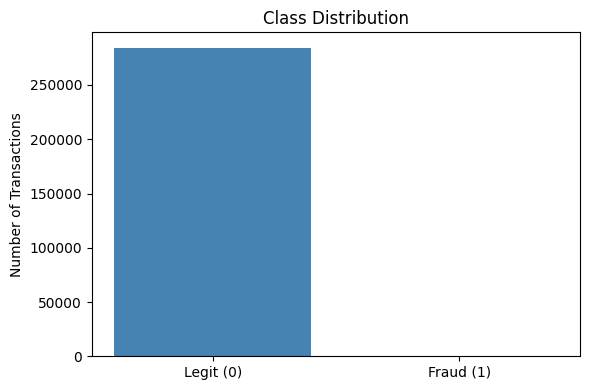

In [96]:
import matplotlib.pyplot as plt

class_counts = credit_card_data['Class'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Legit (0)', 'Fraud (1)'], class_counts, color=['steelblue', 'crimson'])
plt.title('Class Distribution')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig('images/class_distribution.png', dpi=150)
plt.show()

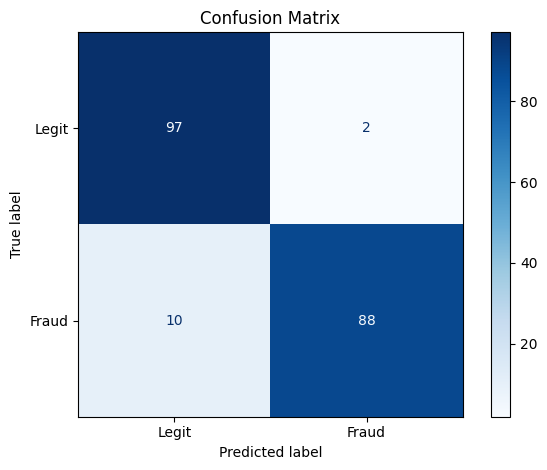

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(Y_test, X_test_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150)
plt.show()

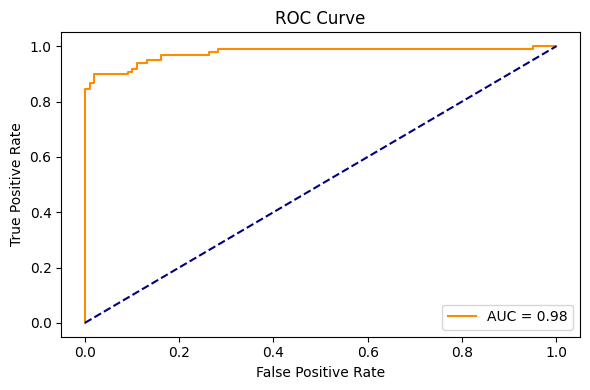

In [98]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(Y_test, model.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/roc_curve.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

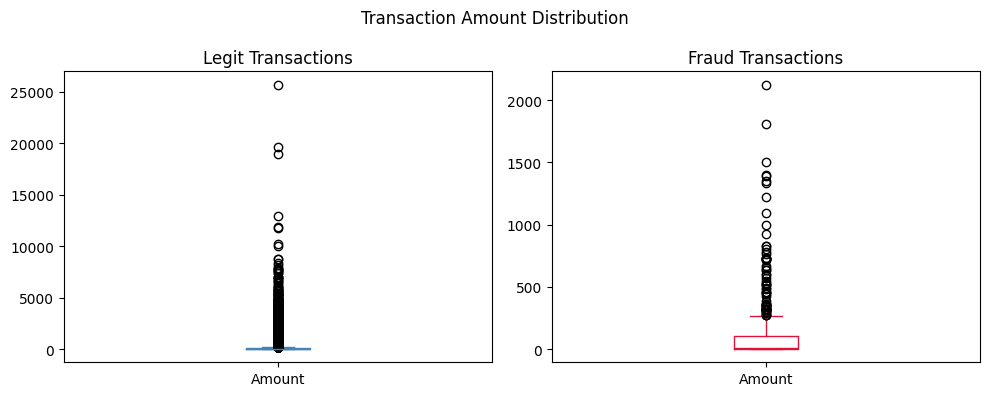

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

credit_card_data[credit_card_data['Class'] == 0]['Amount'].plot(
    kind='box', ax=axes[0], title='Legit Transactions', color='steelblue')
credit_card_data[credit_card_data['Class'] == 1]['Amount'].plot(
    kind='box', ax=axes[1], title='Fraud Transactions', color='crimson')

plt.suptitle('Transaction Amount Distribution')
plt.tight_layout()
plt.savefig('images/amount_distribution.png', dpi=150)
plt.show()